In [2]:
#流
import numpy as np
import matplotlib.pyplot as plt
def liumidu(diyiyinzi,dieryinzi,xquan,k):
    didiyi=2*(diyiyinzi.conjugate()*(xquan)*diyiyinzi-dieryinzi.conjugate()*(xquan)*dieryinzi).imag
    didier=2*k*(diyiyinzi.conjugate()*diyiyinzi+dieryinzi.conjugate()*dieryinzi)
    return didiyi+didier

In [73]:
#x>0的色散关系
import numpy as np
import matplotlib.pyplot as plt
def derivative_value(kx, ky, qx, qy, q, Ef, E):
    return (-4*kx**3+2*kx*(4*qx**2-2*(q**2+ky**2-Ef))+4*qx*(2*ky*qy-E))/(4*qx*kx+2*(2*qy*ky-E))
def get_all_roots(ky, qx, qy, q, Ef, E, const):
    a = -1
    b = 0
    c = 4*qx**2-2*(ky**2-Ef+q**2)
    d = -4*qx*(E-2*ky*qy)
    e = (E-2*ky*qy)**2-(ky**2-Ef+q**2)**2-const**2
    
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    #print(roots_sorted)
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  
        q_negative = []  
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, ky, qx, qy, q, Ef, E)
            if deriv_val > 10**(-128):
                q_positive.append(root)
            elif deriv_val < -10**(-128):
                q_negative.append(root)
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)

        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]
        else:
            if E>0:
                q11, q22, q33, q44 = roots_sorted
            if E<0:
                q11, q22, q33, q44 = roots_sorted
    else:
        if E>0:
            q11, q22, q33, q44 = roots_sorted
        if E<0:
            q11, q22, q33, q44 = roots_sorted
    return q11, q22, q33, q44

In [74]:
#波匹配
def calculate_probabilities_new_method(ky, qx, qy, q, Ef, const, Z, E_set, quedingdewean):
    H = 2*Z*(Ef)**0.5 
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    z_set = []
    z1_set=[]
    for E in E_set:
        if quedingdewean==1:
            qwei = (Ef)**0.5
            bf1 = 1
            bf2 = 0
        if quedingdewean==-1:
            qwei = -(Ef)**0.5
            bf1 = 0
            bf2 = 1
        
        k2 =get_all_roots(ky, qx, qy, q, Ef, E, const)[1].real+1j*abs(get_all_roots(ky, qx, qy, q, Ef, E, const)[1].imag)
        cc1=((k2**2+ky**2-Ef+q**2+2*qy*ky+2*qx*k2)-E)
        af1 = const/(abs(cc1)**2+const**2)**0.5
        af2 = -cc1/(abs(cc1)**2+const**2)**0.5
        #print(abs(af2)**2+abs(af1)**2)

        k4 =get_all_roots(ky, qx, qy, q, Ef, E, const)[3].real+1j*abs(get_all_roots(ky, qx, qy, q, Ef, E, const)[3].imag)
        cc2=((k4**2+ky**2-Ef+q**2+2*qy*ky+2*qx*k4)-E)
        cf1 = const/(abs(cc2)**2+const**2)**0.5
        cf2 = -cc2/(abs(cc2)**2+const**2)**0.5
        #print(abs(cf1)**2+abs(cf2)**2)

        q11 = -(Ef)**0.5
        q33 = (Ef)**0.5

        zuihou1=cf1*(2*(Ef)**0.5-H/(1j)+qx)
        zuihou2=af1*(-H/(1j)+qx)
        zuihou3=cf2*(-H/(1j)-qx)
        zuihou4=af2*(-2*(Ef)**0.5-q33-H/(1j)-qx)
        weiba1=bf1*(qwei-q11)
        weiba2=bf2*(qwei-q33)
        d1=(weiba2-weiba1*zuihou3/zuihou1)/(zuihou4-zuihou2*zuihou3/zuihou1)
        c1=weiba1/zuihou1-d1*zuihou2/zuihou1
        b1 = c1*cf1 + d1*af1 - bf1
        a1 = c1*cf2 + d1*af2 - bf2
        
        ru= liumidu(bf1,bf2,1j*qwei,10**(-6))
        d11=liumidu(d1*af1,d1*af2,-1j*(Ef)**0.5,qx)/ru
        c11=liumidu(c1*cf1,c1*cf2,1j*(Ef)**0.5,qx)/ru
        b11=-liumidu(b1,0,1j*q11,10**(-6))/ru
        a11=-liumidu(0,a1,1j*q33,10**(-6))/ru

        a_set.append(a11)
        b_set.append(b11)
        c_set.append(c11)
        d_set.append(d11)
        z_set.append(c11+d11+a11+b11)
        if quedingdewean==1:
            z1_set.append(1+a11 -b11)
        if quedingdewean==-1:
            z1_set.append(1+b11 -a11)

    return a_set, b_set, c_set, d_set, z_set, z1_set

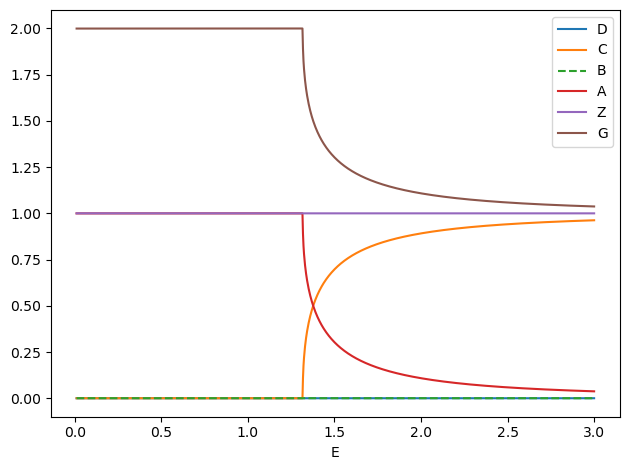

In [86]:
if __name__ == "__main__":
    ky=0
    qx=0.005
    qy=0
    q=(qx**2+qy**2)**0.5
    Ef=1000
    const = Ef/1000
    Z=0.01
    #Z=3
    E_set1 = np.linspace(10**(-2)*const, 3*const, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1, z1_set1 = calculate_probabilities_new_method(ky, qx, qy, q, Ef, const, Z, E_set1, 1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.plot(E_set1, z1_set1, label='G')
    #plt.axhline(y=0.2, color='k', linestyle='-', alpha=0.3)
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.6)
    plt.show()